In [ ]:
! pip install --upgrade xarray zarr gcsfs cftime nc-time-axis
!pip install plotly
!pip install --upgrade nbformat




In [25]:
import os
current_directory = os.getcwd()
print(f"Current working directory: {current_directory}")

PermissionError: [Errno 1] Operation not permitted

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import plotly.express as px
import zarr
import gcsfs
import matplotlib.pyplot as plt
import cartopy
%matplotlib inline

xr.set_options(display_style='html')
%config InlineBackend.figure_format = 'retina' 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

print("NumPy version:", np.__version__)
print("Cartopy version:", ccrs.__name__)  # Should not error


NumPy version: 2.3.4
Cartopy version: cartopy.crs


In [4]:
! pip install xarray zarr gcsfs

In [5]:
import numpy as np
import pandas as pd
import xarray as xr
#import zarr
#import gcsfs
import matplotlib.pyplot as plt
%matplotlib inline


xr.set_options(display_style='html')
%config InlineBackend.figure_format = 'retina' 

In [6]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
#import zarr
import gcsfs

xr.set_options(display_style='html')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [7]:
plt.rcParams['figure.figsize'] = 12, 6

In [8]:
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


In [9]:
precipitation_runoff = df[
   (df['activity_id'] == 'CMIP') &
   (df['experiment_id'] == 'historical') &
   (df['variable_id'].isin(['pr', 'mrro'])) &
   (df['table_id'].isin(['Amon', 'Lmon'])) &
   (df['source_id'] == 'GFDL-ESM4')
]
precipitation_runoff

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
994,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r3i1p1f1,Amon,pr,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,NaN,20180701
1773,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r2i1p1f1,Amon,pr,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,NaN,20180701
244715,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r1i1p1f1,Amon,pr,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,NaN,20190726
244819,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r1i1p1f1,Lmon,mrro,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,NaN,20190726


In [10]:
# ✅ 1. Connect to GCS once
gcs = gcsfs.GCSFileSystem(token='anon')

# ✅ 2. Filter your metadata DataFrame to get the zstore paths
precipitation_runoff = df[
(df['activity_id'] == 'CMIP') &
(df['experiment_id'] == 'historical') &
(df['variable_id'].isin(['pr', 'mrro'])) &
(df['table_id'].isin(['Amon', 'Lmon'])) &
(df['source_id'] == 'GFDL-ESM4')
]

# ✅ 3. Open both datasets lazily (with chunks!)
runoff_mapper = gcs.get_mapper(precipitation_runoff.zstore.values[-1])
precip_mapper = gcs.get_mapper(precipitation_runoff.zstore.values[-2])
ds_runoff = xr.open_zarr(runoff_mapper, consolidated=True)
ds_precip = xr.open_zarr(precip_mapper, consolidated=True)

# ✅ 4. Rename variables for clarity
ds_runoff = ds_runoff.rename({'mrro': 'runoff'})
ds_precip = ds_precip.rename({'pr': 'precipitation'})

# ✅ 5. Merge directly in xarray (fast + lazy)
ds = xr.merge([ds_runoff[['runoff']], ds_precip[['precipitation']]])

# ✅ 6. Optionally, convert units or compute derived variables
# Convert precipitation flux (kg/m²/s) → total monthly precipitation (mm/month)
days_in_month = ds['time'].dt.days_in_month
ds['precipitation_mm'] = ds['precipitation'] * 86400 * days_in_month
ds['precipitation_mm'].attrs['units'] = 'mm/month'
ds['precipitation_mm'].attrs['long_name'] = 'Total Monthly Precipitation'
# Convert runoff flux (kg/m²/s) → total monthly runoff (mm/month)
ds['runoff_mm'] = ds['runoff'] * 86400 * days_in_month
ds['runoff_mm'].attrs['units'] = 'mm/month'
ds['runoff_mm'].attrs['long_name'] = 'Total Monthly Runoff'


# ✅ 7. Compute runoff-to-precipitation ratio (still lazy!)
ds['efficiency'] = ds['runoff'] / ds['precipitation']
ds['efficiency'].attrs['long_name'] = 'Runoff-to-Precipitation Ratio'



In [11]:
ds

<xarray.Dataset> Size: 3GB
Dimensions:           (time: 1980, lat: 180, lon: 288)
Coordinates:
  * time              (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 1...
  * lat               (lat) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon               (lon) float64 2kB 0.625 1.875 3.125 ... 356.9 358.1 359.4
Data variables:
    runoff            (time, lat, lon) float32 411MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    precipitation     (time, lat, lon) float32 411MB 1.209e-06 ... 2.401e-06
    precipitation_mm  (time, lat, lon) float64 821MB 3.238 3.238 ... 6.431 6.431
    runoff_mm         (time, lat, lon) float64 821MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    efficiency        (time, lat, lon) float32 411MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  36500.0
    comment:                <null ref>
    ...                     ...
    table_id:               Lmon
    title:                  NOAA GFDL GFDL-ESM4 model output prepared for CMI...
    tracking_id:            hdl:21.14100/6f075e65-3f76-4d37-8bbd-31e9f3434904...
    variable_id:            mrro
    variant_info:           N/A
    variant_label:          r1i1p1f1

In [12]:
ds['time'] = ds.indexes['time'].to_datetimeindex()

/var/folders/yf/rphrjvld5m9f1mf5tfgxhc3c0000gn/T/ipykernel_15692/2135622427.py:1: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ds['time'] = ds.indexes['time'].to_datetimeindex()
/var/folders/yf/rphrjvld5m9f1mf5tfgxhc3c0000gn/T/ipykernel_15692/2135622427.py:1: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds['time'] = ds.indexes['time'].to_datetimeindex()


In [13]:
df = ds.to_dataframe().reset_index()  
df 

,time,lat,lon,runoff,precipitation,precipitation_mm,runoff_mm,efficiency
0,1850-01-16 12:00:00,-89.5,0.625,0.0,0.000001,3.237561,0.0,0.0
1,1850-01-16 12:00:00,-89.5,1.875,0.0,0.000001,3.237561,0.0,0.0
2,1850-01-16 12:00:00,-89.5,3.125,0.0,0.000001,3.237561,0.0,0.0
3,1850-01-16 12:00:00,-89.5,4.375,0.0,0.000001,3.237561,0.0,0.0
4,1850-01-16 12:00:00,-89.5,5.625,0.0,0.000001,3.237561,0.0,0.0
...,...,...,...,...,...,...,...,...
102643195,2014-12-16 12:00:00,89.5,354.375,0.0,0.000002,6.430883,0.0,0.0
102643196,2014-12-16 12:00:00,89.5,355.625,0.0,0.000002,6.430883,0.0,0.0
102643197,2014-12-16 12:00:00,89.5,356.875,0.0,0.000002,6.430883,0.0,0.0
102643198,2014-12-16 12:00:00,89.5,358.125,0.0,0.000002,6.430883,0.0,0.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102643200 entries, 0 to 102643199
Data columns (total 8 columns):
 #   Column            Dtype         
---  ------            -----         
 0   time              datetime64[ns]
 1   lat               float64       
 2   lon               float64       
 3   runoff            float32       
 4   precipitation     float32       
 5   precipitation_mm  float64       
 6   runoff_mm         float64       
 7   efficiency        float32       
dtypes: datetime64[ns](1), float32(3), float64(4)
memory usage: 5.0 GB


In [15]:
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df.head()

,time,lat,lon,runoff,precipitation,precipitation_mm,runoff_mm,efficiency,year,month
0,1850-01-16 12:00:00,-89.5,0.625,0.0,0.000001,3.237561,0.0,0.0,1850,1
1,1850-01-16 12:00:00,-89.5,1.875,0.0,0.000001,3.237561,0.0,0.0,1850,1
2,1850-01-16 12:00:00,-89.5,3.125,0.0,0.000001,3.237561,0.0,0.0,1850,1
3,1850-01-16 12:00:00,-89.5,4.375,0.0,0.000001,3.237561,0.0,0.0,1850,1
4,1850-01-16 12:00:00,-89.5,5.625,0.0,0.000001,3.237561,0.0,0.0,1850,1


In [16]:
# groupby year and lat and lon to get annual mean for precipitation
annual_precipitation = df.groupby(['year', 'lat', 'lon'])['precipitation_mm'].mean().reset_index()
annual_precipitation

,year,lat,lon,precipitation_mm
0,1850,-89.5,0.625,3.058164
1,1850,-89.5,1.875,3.058164
2,1850,-89.5,3.125,3.058164
3,1850,-89.5,4.375,3.058164
4,1850,-89.5,5.625,3.058164
...,...,...,...,...
8553595,2014,89.5,354.375,17.596488
8553596,2014,89.5,355.625,17.596488
8553597,2014,89.5,356.875,17.596488
8553598,2014,89.5,358.125,17.596488


In [17]:


# Assuming your DataFrame is called df
# Replace infinities or zeros in precipitation to avoid division errors
df['efficiency'] = np.where(df['precipitation_mm'] > 0, df['runoff_mm'] / df['precipitation_mm'], np.nan)


# Aggregate by lat/lon (mean efficiency over time)
eff_map = df.groupby(['lat', 'lon'])['efficiency'].mean().reset_index()


In [18]:
# Replace tiny negatives with 0
df['efficiency'] = df['efficiency'].clip(lower=0)

# Remove absurdly high values (e.g., >1)
df['efficiency'] = df['efficiency'].mask(df['efficiency'] > 1, np.nan)

# Optional: check again
print(df['efficiency'].describe())


count    9.969608e+07
mean     3.366721e-02
std      1.135825e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.999993e-01
Name: efficiency, dtype: float64


/Users/claudinemaurahandali/opt/anaconda3/envs/cmip_env/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/claudinemaurahandali/opt/anaconda3/envs/cmip_env/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/claudinemaurahandali/opt/anaconda3/envs/cmip_env/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/claudinemaurahandali/opt/anaconda3/envs/cmip_env/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Use

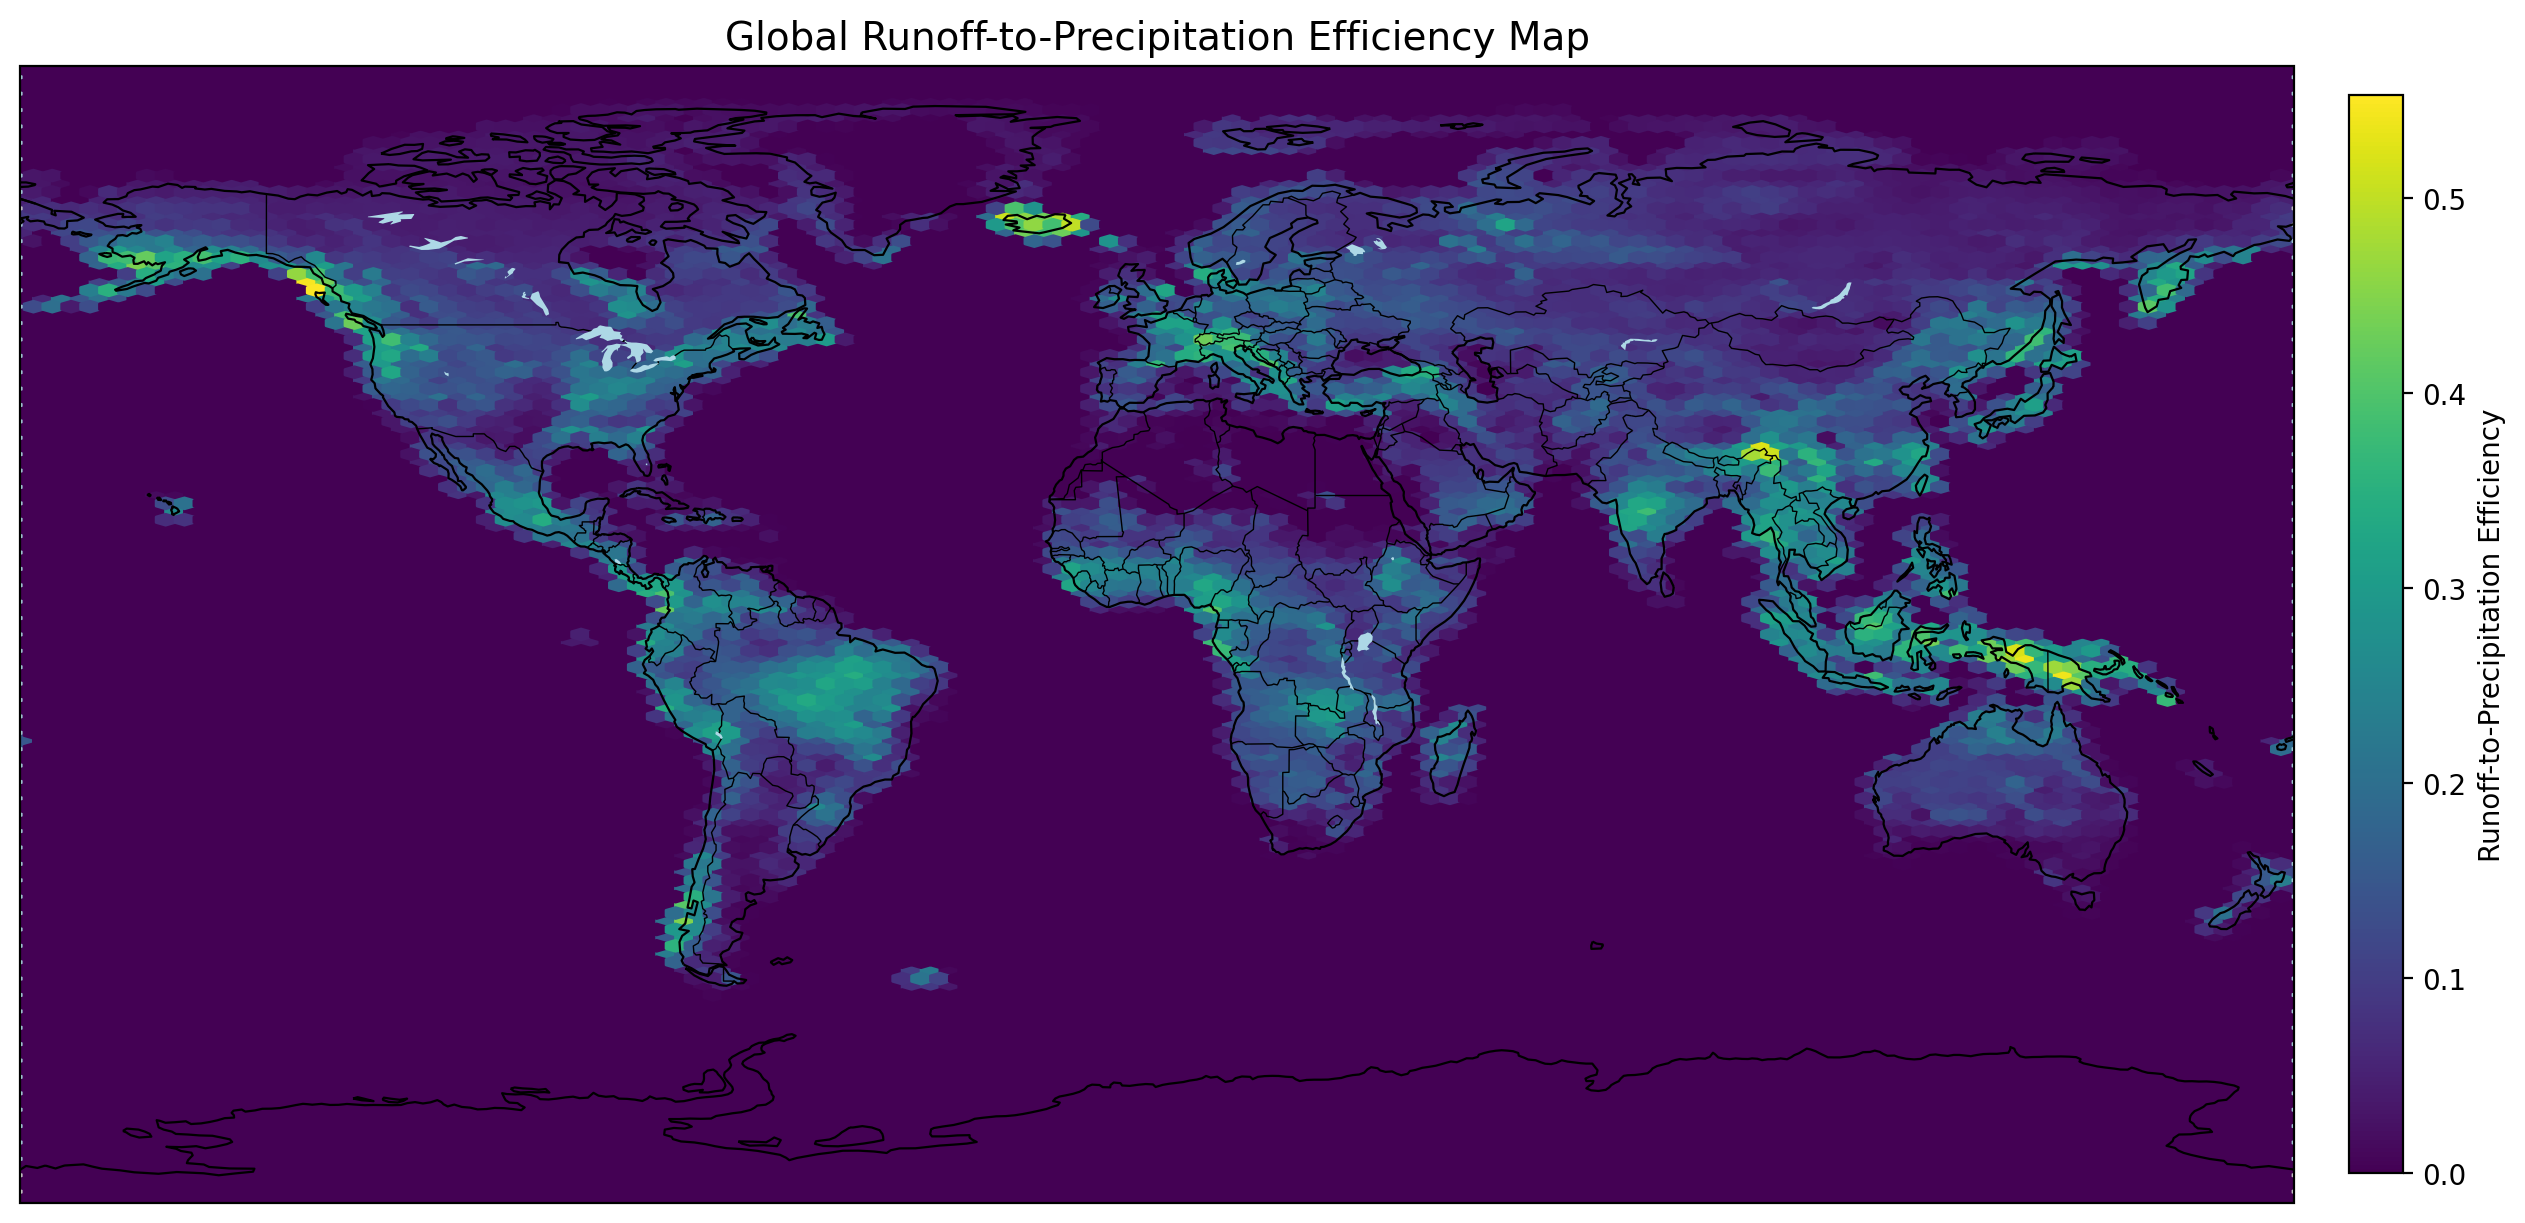

In [19]:


if df['lon'].max() > 180:
    df['lon'] = df['lon'].apply(lambda x: x - 360 if x > 180 else x)

df_plot = df[df['efficiency'].notna()]

plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()

# Base map
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.LAKES, facecolor='lightblue')

# Hexbin plot
hb = ax.hexbin(
    df_plot['lon'], df_plot['lat'],
    C=df_plot['efficiency'],
    gridsize=120,
    cmap='viridis',
    mincnt=1,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(hb, orientation='vertical', shrink=0.7, pad=0.02)
cbar.set_label('Runoff-to-Precipitation Efficiency')

plt.title('Global Runoff-to-Precipitation Efficiency Map', fontsize=14)
plt.tight_layout()
plt.show()
